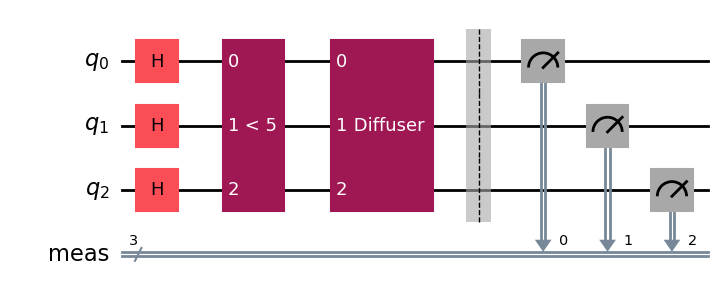

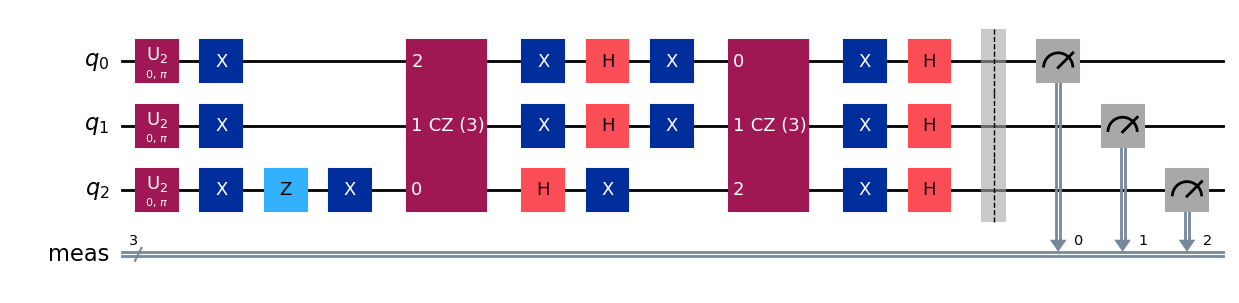


Measurement outcomes:
0:000 → 32
1:001 → 40
2:010 → 30
3:011 → 34
4:100 → 30
5:101 → 259
6:110 → 276
7:111 → 323


In [9]:
# Imports
import Oracles as func
from math import sqrt, pi, ceil, log2, floor, asin
from statistics import fmean
import numpy as np

import configparser

import networkx as nx
import matplotlib.pyplot as plt

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import (QuantumCircuit, QuantumRegister, transpile, ClassicalRegister)
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector


from qiskit.qasm3 import dump, dumps

import pickle
from alive_progress import alive_bar
from time import strftime
from IPython.display import display

def amplitude_amplification_superposition(threshold):
 
    num_qubits = ceil(log2(threshold+1))+1
        
    M = 2 ** num_qubits

    log_n_floor = floor(log2(threshold+1))
    numerator = 2 ** log_n_floor
    theta = np.arccos(1 - numerator / threshold)  # Compute phase shift

    qc = QuantumCircuit(num_qubits, name="AA_superposition")
    
    # Step 1: Create uniform superposition.
    qc.h(range(num_qubits))  
    return qc, num_qubits, log_n_floor, theta


def simple_test():
     # Less than oracle
    number_less_than = 5
    num_qubits = 3
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))  

    less = func.oracle_less_than(number=number_less_than, nqubits=num_qubits)
    qc.append(less, range(num_qubits))
    #diffuser = func.diffuser(num_qubits)
    #qc.append(diffuser, range(num_qubits))
    
    diffuser = QuantumCircuit(num_qubits, name=' Diffuser ')

    diffuser.h(range(num_qubits))
    diffuser.x(range(num_qubits))
    diffuser.append(func.multi_control_z(num_qubits), range(num_qubits))
    diffuser.x(range(num_qubits))
    diffuser.h(range(num_qubits))

    qc.append(diffuser, range(num_qubits))
    qc.measure_all()

    fig = qc.draw(output='mpl')
    display(fig)
    fig = qc.decompose().draw(output='mpl')
    display(fig)
    
    backend = Aer.get_backend('aer_simulator_statevector')
    qc = transpile(qc, backend)
    result = backend.run(qc).result()
    counts = result.get_counts()

    sorted_counts = dict(sorted(counts.items(), key=lambda item: int(item[0], 2)))
    print("\nMeasurement outcomes:")
    for state, count in sorted_counts.items():
        decimal_value = int(state, 2)  # Convert binary string to decimal
        print(f"{decimal_value}:{state} → {count}")
    '''
    qc = transpile(qc, backend)
    job = backend.run(qc, shots=2000,memory=True)
    result = job.result()
    counts = result.get_counts()

    #Pretty printing
    sorted_counts = dict(sorted(counts.items(), key=lambda item: int(item[0], 2)))
    print("\nMeasurement outcomes:")
    for state, count in sorted_counts.items():
        decimal_value = int(state, 2)  # Convert binary string to decimal
        print(f"{decimal_value}:{state} → {count}")
    '''
if __name__=='__main__':
    simple_test()